<a href="https://colab.research.google.com/github/CassioLima09/NLP_with_Transformers/blob/main/09_few-to-no-labels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Uncomment and run this cell if you're on Colab or Kaggle
# !git clone https://github.com/nlp-with-transformers/notebooks.git
# %cd notebooks
# from install import *
# install_requirements()

In [ ]:
# hide
from utils import *
setup_chapter()

2021-10-28 08:22:42.962790: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2021-10-28 08:22:42.962821: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


Using transformers v4.11.3
Using datasets v1.13.0
Using accelerate v0.5.1


# Dealing with Few to No Labels

<img alt="decision-tree" caption="Several techniques that can be used to improve model performance in the absence of large amounts of labeled data" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter09_decision-tree.png?raw=1" id="decision-tree"/>

## Building a GitHub Issues Tagger

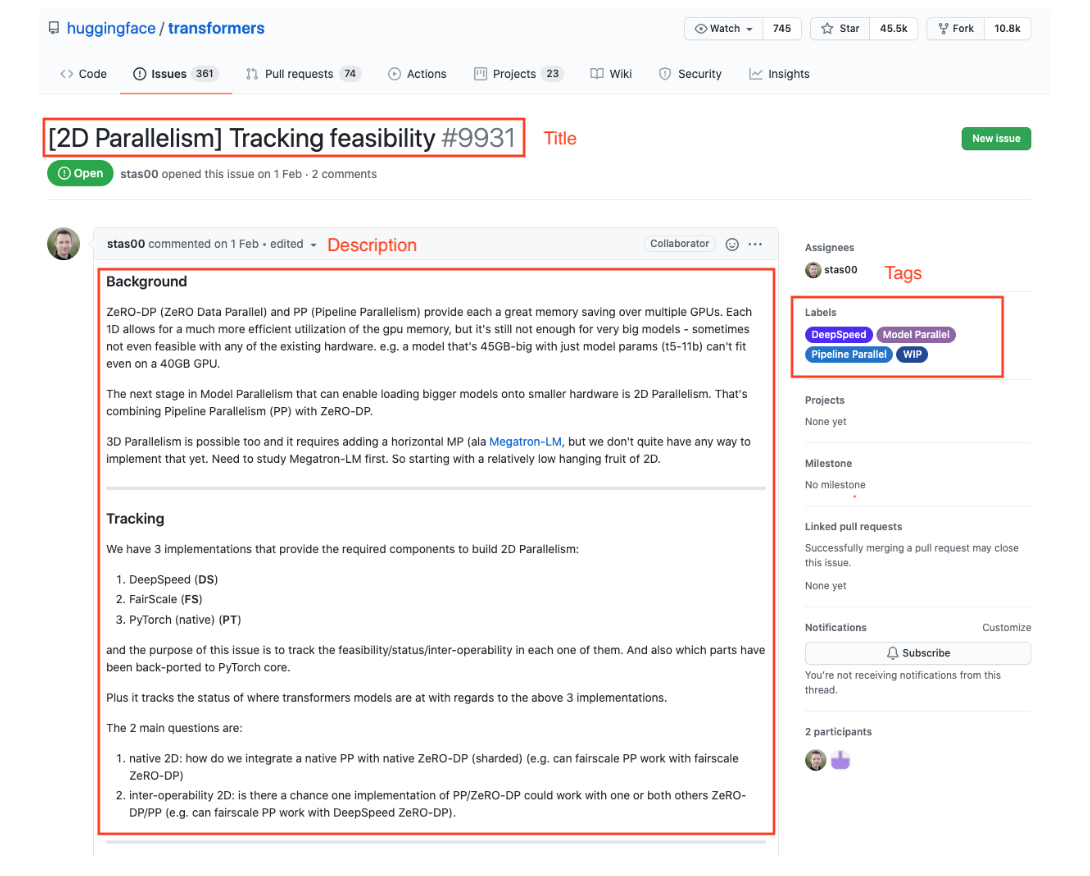

### Getting the Data

#hide
### REPO ONLY: Code to Download Issues
If you want to download the issues yourself, you can query the Issues endpoint by using the _Requests_ library, which is the standard way for making HTTP requests in Python. Here is a function to fetch the issues from the Transformers repository:

In [ ]:
#hide
import time
import math
import requests
from pathlib import Path
import pandas as pd
from tqdm.auto import tqdm

def fetch_issues(owner="huggingface", repo="transformers", num_issues=10_000,
                 rate_limit=5_000):
    batch = []
    all_issues = []
    per_page = 100 # Number of issues to return per page
    num_pages = math.ceil(num_issues / per_page)
    base_url = "https://api.github.com/repos"

    for page in tqdm(range(num_pages)):
        # Query with state=all to get both open and closed issues
        query = f"issues?page={page}&per_page={per_page}&state=all"
        issues = requests.get(f"{base_url}/{owner}/{repo}/{query}")
        batch.extend(issues.json())

        if len(batch) > rate_limit and len(all_issues) < num_issues:
            all_issues.extend(batch)
            batch = [] # Flush batch for next time period
            print(f"Reached GitHub rate limit. Sleeping for one hour ...")
            time.sleep(60 * 60 + 1)

    all_issues.extend(batch)
    df = pd.DataFrame.from_records(all_issues)
    df.to_json(f"github-issues-{repo}.jsonl", orient="records", lines=True)

#hide

Now when you call `fetch_issues()`, it will download all the issues in batches to avoid exceeding GitHub's limit on the number of requests per hour. The results will be stored in an _github-issues-transformers.jsonl_ file, where each line is a JSON object the represents the issue.

### Preparing the Data

In [ ]:
import pandas as pd
# VAMOS BAIXAR O DATAET
dataset_url = "https://git.io/nlp-with-transformers"
df_issues = pd.read_json(dataset_url, lines=True)
print(f"DataFrame shape: {df_issues.shape}")

DataFrame shape: (9930, 26)


In [ ]:
cols = ["url", "id", "title", "user", "labels", "state", "created_at", "body"]
df_issues.loc[2, cols].to_frame()

,2
url,https://api.github.com/repos/huggingface/trans...
id,849529761
title,[DeepSpeed] ZeRO stage 3 integration: getting ...
user,"{'login': 'stas00', 'id': 10676103, 'node_id':..."
labels,"[{'id': 2659267025, 'node_id': 'MDU6TGFiZWwyNj..."
state,open
created_at,2021-04-02 23:40:42
body,"**[This is not yet alive, preparing for the re..."


In [ ]:
# NESSE Json temos muitas informações das labels, mas queremos apenas seu nome,
# por isso vamos reescrever o conteudo para constar apenas o nome
df_issues["labels"] = (df_issues["labels"]
                       .apply(lambda x: [meta["name"] for meta in x]))
df_issues[["labels"]].head()

,labels
0,[]
1,[]
2,[DeepSpeed]
3,[]
4,[]


In [ ]:
# vamos ver quantas labels cada problema tem
df_issues["labels"].apply(lambda x : len(x)).value_counts().to_frame().T

,0,1,2,3,4,5
labels,6440,3057,305,100,25,3


In [ ]:
df_counts = df_issues["labels"].explode().value_counts()
print(f"Number of labels: {len(df_counts)}")
# Display the top-8 label categories
df_counts.to_frame().head(8).T

#temos 65 labels distintas e estao bem desbalanceadas

Number of labels: 65


,wontfix,model card,Core: Tokenization,New model,Core: Modeling,Help wanted,Good First Issue,Usage
labels,2284,649,106,98,64,52,50,46


In [ ]:
# vamos trabalhar apenas com algumas labels (abaixo)
# vamos renomear essas labels para facilitar a análise

label_map = {"Core: Tokenization": "tokenization",
             "New model": "new model",
             "Core: Modeling": "model training",
             "Usage": "usage",
             "Core: Pipeline": "pipeline",
             "TensorFlow": "tensorflow or tf",
             "PyTorch": "pytorch",
             "Examples": "examples",
             "Documentation": "documentation"}
# vamos ver a distribuiçao dessas labels
def filter_labels(x):
    return [label_map[label] for label in x if label in label_map]

df_issues["labels"] = df_issues["labels"].apply(filter_labels)
all_labels = list(label_map.values())

In [ ]:
df_counts = df_issues["labels"].explode().value_counts()
df_counts.to_frame().T

,tokenization,new model,model training,usage,pipeline,tensorflow or tf,pytorch,documentation,examples
labels,106,98,64,46,42,41,37,28,24


In [ ]:
# vamos criar uma coluna que diz se é unlabled
# define todos como unlabeles
df_issues["split"] = "unlabeled"
# cria uma mascara onde se tiver alguma label sai como true
mask = df_issues["labels"].apply(lambda x: len(x)) > 0

# em split, ele busca todos que tem mascara 1 (labeled) e altera
df_issues.loc[mask, "split"] = "labeled"
df_issues["split"].value_counts().to_frame()

,split
unlabeled,9489
labeled,441


In [ ]:
# vamos ver um exemplo do nosso dataet
for column in ["title", "body", "labels"]:
    print(f"{column}: {df_issues[column].iloc[26][:500]}\n")

title: Add new CANINE model

body: # 🌟 New model addition

## Model description

Google recently proposed a new **C**haracter **A**rchitecture with **N**o tokenization **I**n **N**eural **E**ncoders architecture (CANINE). Not only the title is exciting:

> Pipelined NLP systems have largely been superseded by end-to-end neural modeling, yet nearly all commonly-used models still require an explicit tokenization step. While recent tokenization approaches based on data-derived subword lexicons are less brittle than manually en

labels: ['new model']



In [ ]:
# percebemos que o nosso titulo tem informações importantes
# por isso vamos junta-lo com nosso body
df_issues["text"] = (df_issues
                     .apply(lambda x: x["title"] + "\n\n" + x["body"], axis=1))

In [ ]:
# vamos retirar textos duplicados
len_before = len(df_issues)
df_issues = df_issues.drop_duplicates(subset="text")
print(f"Removed {(len_before-len(df_issues))/len_before:.2%} duplicates.")

Removed 1.88% duplicates.


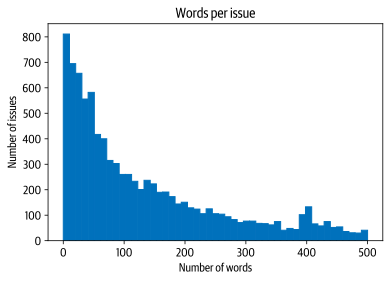

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# vamos ver o numero de palavras em cada texto do dataset
(df_issues["text"].str.split().apply(len)
 .hist(bins=np.linspace(0, 500, 50), grid=False, edgecolor="C0"))
plt.title("Words per issue")
plt.xlabel("Number of words")
plt.ylabel("Number of issues")
plt.show()

### Creating Training Sets

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer
# para problemas multiclasse, criar um set de treino e validação
#pode ser dificil
# para isso usamos a biblioteca Scikit-multilearn
# agora vamos criar uma instancia que binariza de acordo com as classs presentes
mlb = MultiLabelBinarizer()
#o fit é usado para aprender todos os rotulos disponiveis
mlb.fit([all_labels])

# agora vamos testar em 2 exemplos, um com 2 classes e outro com uma classe só
# veremos como fica a binarização
#mlb.transform([["tokenization", "new model"], ["pytorch"]])

array([[0, 0, 0, 1, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0]])

In [ ]:
#O train_test_split do scikit-learn não trata bem multilabel:
#ele pode gerar um conjunto de treino sem nenhuma ocorrência de algumas labels.
# solução :iterative_train_test_split, mantem proporçao em classes ate em problemas
#multiclasse
from skmultilearn.model_selection import iterative_train_test_split
# vamos fazer o split em treino e teste, usando uma função que que considera
# o balanceamento entre classes em problemas multiclasse
# a função espera uma matriz 2d para transformar em dataframe
def balanced_split(df, test_size=0.5):
# a funçao iterative_train_test_split exige que a entrada tenha 2 dimensoes
#mesmo que seja só um indice
    ind = np.expand_dims(np.arange(len(df)), axis=1)# coloca o indice em 2d
    #[0], [1], [2], ..., [n-1] → formato 2D
    labels = mlb.transform(df["labels"])
    #vamos recuperar apenas os indices que queremos
    ind_train, _, ind_test, _ = iterative_train_test_split(ind, labels,
                                                           test_size)
    # cm os indices de interesse, vamos montar nosso dataset
    return df.iloc[ind_train[:, 0]], df.iloc[ind_test[:,0]]

In [ ]:
from sklearn.model_selection import train_test_split
# organiza um pipeline de separação dos dados entre supervisionados e
# não supervisionados, e depois divide os supervisionados em treino,
#validação e teste
# cria um dataset limpo
#"split": indica se o exemplo é "labeled" ou "unlabeled" (como vimos antes).
#reset_index(drop=True) para garantir índices limpos (recontagem de 0 em diante).
#.copy() para evitar modificações não intencionais no df_issues original.
df_clean = df_issues[["text", "labels", "split"]].reset_index(drop=True).copy()
# selecionamos os nao supervisionados
df_unsup = df_clean.loc[df_clean["split"] == "unlabeled", ["text", "labels"]]
# selecionamos os supervisionados
df_sup = df_clean.loc[df_clean["split"] == "labeled", ["text", "labels"]]
# vamos garantir a reprodutibilidade dos splits
np.random.seed(0)
# separamos agora os dados com rotulo
df_train, df_tmp = balanced_split(df_sup, test_size=0.5)
df_valid, df_test = balanced_split(df_tmp, test_size=0.5)

In [ ]:
from datasets import Dataset, DatasetDict
# vamos criar nosso dataset dict
ds = DatasetDict({
    "train": Dataset.from_pandas(df_train.reset_index(drop=True)),
    "valid": Dataset.from_pandas(df_valid.reset_index(drop=True)),
    "test": Dataset.from_pandas(df_test.reset_index(drop=True)),
    "unsup": Dataset.from_pandas(df_unsup.reset_index(drop=True))})

### Creating Training Slices

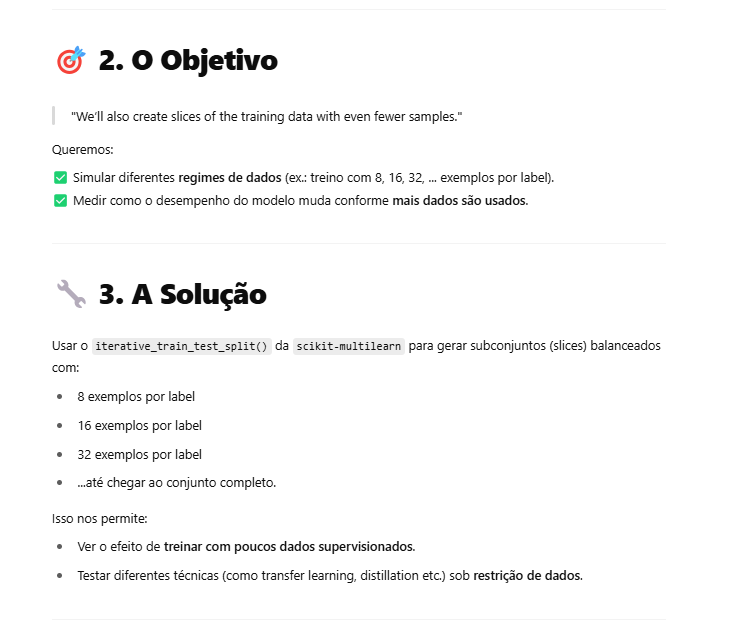

In [ ]:
#O conjunto de dados tem duas características que queremos estudar:
#Poucos dados rotulados (sparse labeled data)
#Classificação multilabel (multilabel classification)

np.random.seed(0)
# geramos os indices em 2d para fazer o split
all_indices = np.expand_dims(list(range(len(ds["train"]))), axis=1)
# coletamos os indices
indices_pool = all_indices
# fazemos a transformação em binario
labels = mlb.transform(ds["train"]["labels"])
# escolhemos os testes de numero de samples de cada label
train_samples = [8, 16, 32, 64, 128]
train_slices, last_k = [], 0
# loop para criar os slices
for i, k in enumerate(train_samples):
    # Split off samples necessary to fill the gap to the next split size
#Pega mais algumas amostras balanceadas, suficientes para aumentar o slice de last_k para k.

#(k - last_k) / len(labels) define a proporção do novo slice.
# separamos em treino e teste, sendo que atualizamos nosso indices poll para ser o novo treino
#esse novo indices poll perde os dados que agora sao "teste" e estao em new slice
    indices_pool, labels, new_slice, _ = iterative_train_test_split(
        indices_pool, labels, (k-last_k)/len(labels))
    last_k = k
    # se for o primeiro slice ele apenas adiciona, senao concatena com todos os outros
    if i==0: train_slices.append(new_slice)
    else: train_slices.append(np.concatenate((train_slices[-1], new_slice)))

# Add full dataset as last slice
# alem dos slices que definimos, queremos comparar com o tamanho total
#do dataset de treino completo
# por isso adicionamos todos os indices do dataset de treino completo
#e tambem adicionamos os indices de todos eles
train_slices.append(all_indices), train_samples.append(len(ds["train"]))

#todos os slices estavam com shape (N, 1) (duas dimensões), por causa da expand_dims feita no início.
#Aqui, remove-se a segunda dimensão, transformando para shape (N,).
train_slices = [np.squeeze(train_slice) for train_slice in train_slices]

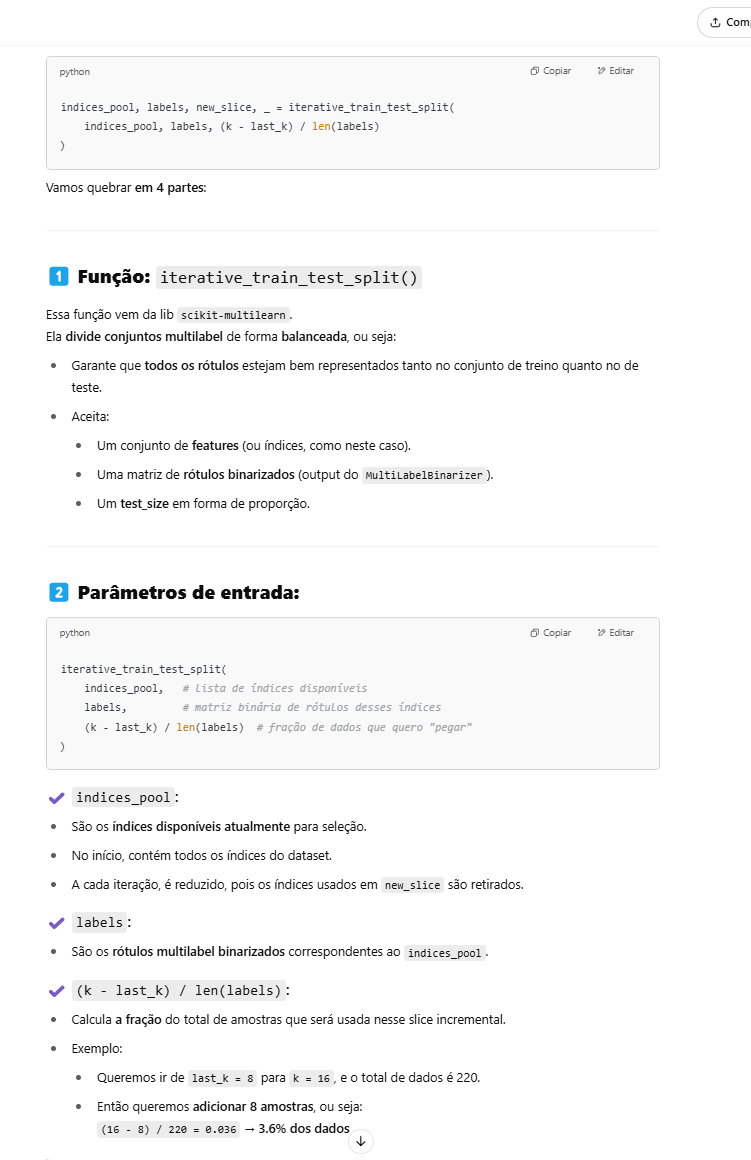

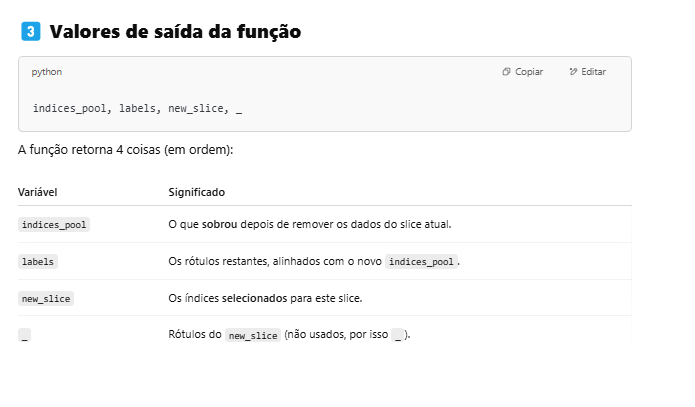

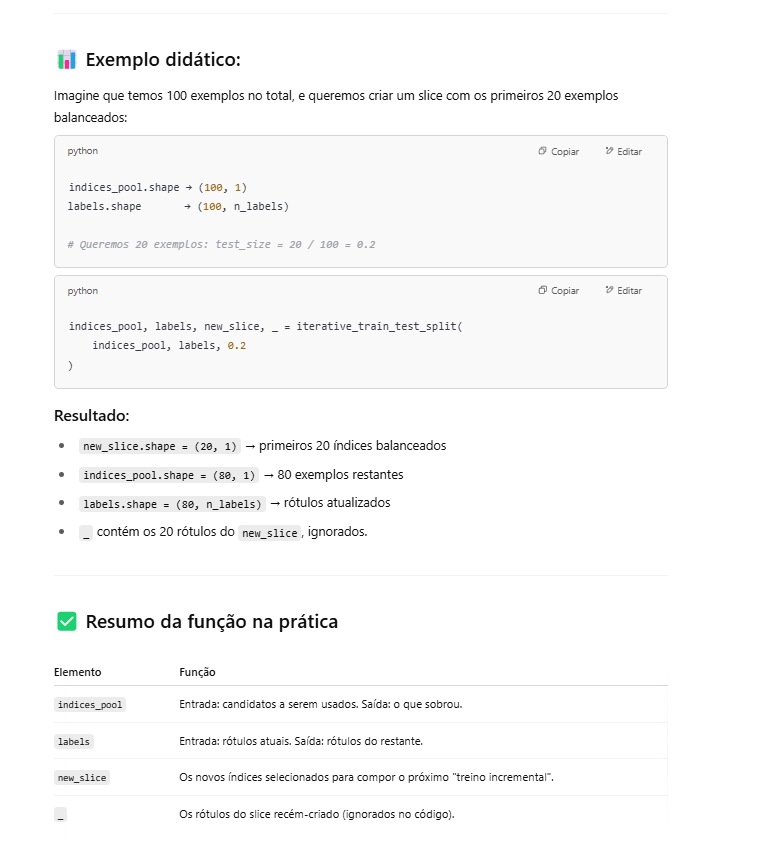

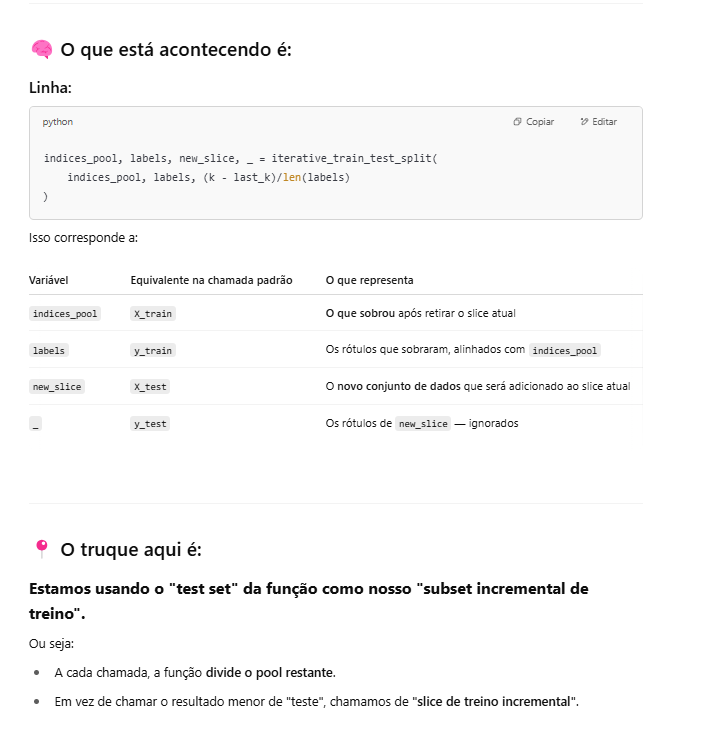

In [ ]:
print("Target split sizes:")
print(train_samples)
print("Actual split sizes:")
print([len(x) for x in train_slices])
# note que esse metodo nao iguala e apenas aproxima o nosso tamanho desejado
#isso porque é dificil alcançar um balanceamento dos dados nos valores que definimos

Target split sizes:
[8, 16, 32, 64, 128, 223]
Actual split sizes:
[10, 19, 36, 68, 134, 223]


## Implementing a Naive Bayesline

Whenever you start a new NLP project, it’s always a good idea to implement a set of strong baselines. There are two main reasons for this:

1. A baseline based on regular expressions, handcrafted rules, or a very simple model might already work really well to solve the problem. In these cases, there is no reason to bring out big guns like transformers, which are generally more complex to deploy and maintain in production environments.

2. The baselines provide quick checks as you explore more complex models. For example, suppose you train BERT-large and get an accuracy of 80% on your validation set. You might write it off as a hard dataset and call it a day. But what if you knew that a simple classifier like logistic regression gets 95% accuracy? That would raise your suspicions and prompt you to debug your model.

So let’s start our analysis by training a baseline model. For text classification, a great baseline is a Naive Bayes classifier as it is very simple, quick to train, and fairly robust to perturbations in the inputs. The Scikit-learn implementation of Naive Bayes does not support multilabel classification out of the box, but fortunately we can again use the Scikit-multilearn library to cast the problem as a one-versus-rest classification task where we train L binary classifiers for L labels. First, let’s use a multilabel binarizer to create a new label_ids column in our training sets. We can use the map() function to take care of all the processing in one go:

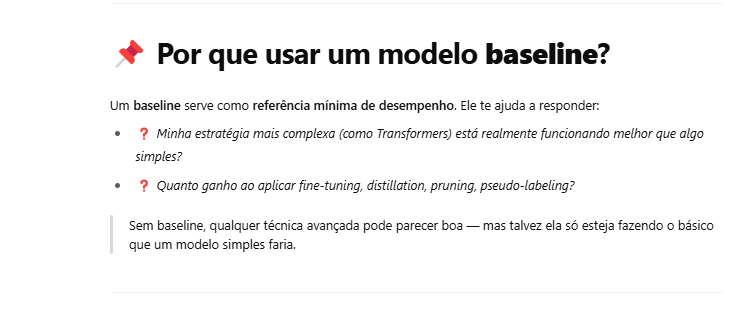

In [ ]:
#hide_output
def prepare_labels(batch):
    batch["label_ids"] = mlb.transform(batch["labels"])
    return batch

ds = ds.map(prepare_labels, batched=True)

  0%|          | 0/1 [00:00<?, ?ba/s]

  0%|          | 0/1 [00:00<?, ?ba/s]

  0%|          | 0/1 [00:00<?, ?ba/s]

  0%|          | 0/10 [00:00<?, ?ba/s]

In [ ]:
from collections import defaultdict
#lembre-se que temos diferentes tamanhos de split que terao diferentes resultados
#as metricas serao a macro e micro f1 score
#antes vamos criar um dicionario padrao para essas metricas
# o dicionario depois vai receber o numero do split e o resultado
macro_scores, micro_scores = defaultdict(list), defaultdict(list)

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
#transforma um problema multilabel em varios problemas binarios independentes
from skmultilearn.problem_transform import BinaryRelevance
from sklearn.feature_extraction.text import CountVectorizer
#vamso usar o skmultilearn para aplicar o naive bays a problmas multiclasse
for train_slice in train_slices:
    # Get training slice and test data
    ds_train_sample = ds["train"].select(train_slice)
    #label_ids são multilabels já transformadas em binários (com MultiLabelBinarizer antes).
    y_train = np.array(ds_train_sample["label_ids"])
    y_test = np.array(ds["test"]["label_ids"])
    # Use a simple count vectorizer to encode our texts as token counts
    #essa é a tecnica de bag of words e desconsideramos qualquer contexto
    # o BoW assume a independencia entre palavras, assim como o naive bayes
    count_vect = CountVectorizer()
    X_train_counts = count_vect.fit_transform(ds_train_sample["text"])
    X_test_counts = count_vect.transform(ds["test"]["text"])
    # Create and train our model!
    #BinaryRelevance vai criar umm modelo para cada label
    #cada modelo vai prever a presença ou ausencia daquele rótulo
    classifier = BinaryRelevance(classifier=MultinomialNB())
    classifier.fit(X_train_counts, y_train)
    # Generate predictions and evaluate
    y_pred_test = classifier.predict(X_test_counts)
    clf_report = classification_report(
        y_test, y_pred_test, target_names=mlb.classes_, zero_division=0,
        output_dict=True)
    # Store metrics
    macro_scores["Naive Bayes"].append(clf_report["macro avg"]["f1-score"])
    micro_scores["Naive Bayes"].append(clf_report["micro avg"]["f1-score"])
#macro avg: média igual para todas as classes

#micro avg: média ponderada pelo número de exemplos por classe

In [ ]:
import matplotlib.pyplot as plt

def plot_metrics(micro_scores, macro_scores, sample_sizes, current_model):
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    for run in micro_scores.keys():
        if run == current_model:
            ax0.plot(sample_sizes, micro_scores[run], label=run, linewidth=2)
            ax1.plot(sample_sizes, macro_scores[run], label=run, linewidth=2)
        else:
            ax0.plot(sample_sizes, micro_scores[run], label=run,
                     linestyle="dashed")
            ax1.plot(sample_sizes, macro_scores[run], label=run,
                     linestyle="dashed")

    ax0.set_title("Micro F1 scores")
    ax1.set_title("Macro F1 scores")
    ax0.set_ylabel("Test set F1 score")
    ax0.legend(loc="lower right")
    for ax in [ax0, ax1]:
        ax.set_xlabel("Number of training samples")
        ax.set_xscale("log")
        ax.set_xticks(sample_sizes)
        ax.set_xticklabels(sample_sizes)
        ax.minorticks_off()
    plt.tight_layout()
    plt.show()

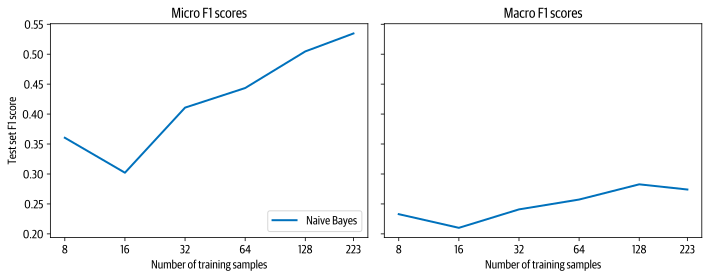

In [ ]:
plot_metrics(micro_scores, macro_scores, train_samples, "Naive Bayes")

Note that we plot the number of samples on a logarithmic scale. From the figure we can see that the micro and macro F -scores both improve as we increase the number of training samples. With so few samples to train on, the results are also slightly noisy since each slice can have a different class distribution. Nevertheless, what’s important here is the trend, so let’s now see how these results fare against transformer-based approaches!

## Working with No Labeled Data

The first technique that we’ll consider is zero-shot classification, which is suitable in settings where you have no labeled data at all. This is surprisingly common in industry, and might occur because there is no historic data with labels or because acquiring the labels for the data is difficult. We will cheat a bit in this section since we will still use the test data to measure the performance, but we will not use any data to train the model (otherwise the comparison to the following approaches would be difficult).

The goal of zero-shot classification is to make use of a pretrained model without any additional fine-tuning on your task-specific corpus. To get a better idea of how this could work, recall that language models like BERT are pretrained to predict masked tokens in text on thousands of books and large Wikipedia dumps. To successfully predict a missing token, the model needs to be aware of the topic in the context. We can try to trick the model into classifying a document for us by providing a sentence like:

“This section was about the topic [MASK].”
The model should then give a reasonable suggestion for the document’s topic, since this is a natural text to occur in the dataset.
2

**The first thing to try is to load BERT-base in the fill-mask pipeline, which uses the masked language model to predict the content of the masked tokens:**

O ideal tambem é usar um modelo que foi pré-treinado em uma tarefa de classificação.

In [ ]:
#hide_output
from transformers import pipeline

pipe = pipeline("fill-mask", model="bert-base-uncased")

In [ ]:
#vamos fazer um teste
movie_desc = "The main characters of the movie madacascar \
are a lion, a zebra, a giraffe, and a hippo. "
prompt = "The movie is about [MASK]."

output = pipe(movie_desc + prompt)
for element in output:
    print(f"Token {element['token_str']}:\t{element['score']:.3f}%")
    #o modelo gera as probabilidades de saída para preencher a mascara

Token animals:  0.103%
Token lions:    0.066%
Token birds:    0.025%
Token love:     0.015%
Token hunting:  0.013%


In [ ]:
#podemos colocar targets
output = pipe(movie_desc + prompt, targets=["animals", "cars"])
for element in output:
    print(f"Token {element['token_str']}:\t{element['score']:.3f}%")

Token animals:  0.103%
Token cars:     0.001%


In [ ]:
movie_desc = "In the movie transformers aliens \
can morph into a wide range of vehicles."

output = pipe(movie_desc + prompt, targets=["animals", "cars"])
for element in output:
    print(f"Token {element['token_str']}:\t{element['score']:.3f}%")

Token cars:     0.139%
Token animals:  0.006%


In [ ]:
from transformers import pipeline
#vamos usar um modelo especifico para classificaçaõ

pipe = pipeline("zero-shot-classification", device=0)

In [ ]:
sample = ds["train"][0]
print(f"Labels: {sample['labels']}")
# apenas precisamos passar o texto e as labels
output = pipe(sample["text"], all_labels, multi_label=True)
print(output["sequence"][:400])
print("\nPredictions:")

for label, score in zip(output["labels"], output["scores"]):
    print(f"{label}, {score:.2f}")

  #pelo que entendi ele passa por cada classe e ve a probabilidade dessa classe

Labels: ['new model']
Add new CANINE model

# 🌟 New model addition

## Model description

Google recently proposed a new **C**haracter **A**rchitecture with **N**o
tokenization **I**n **N**eural **E**ncoders architecture (CANINE). Not only the
title is exciting:

> Pipelined NLP systems have largely been superseded by end-to-end neural
modeling, yet nearly all commonly-used models still require an explicit tokeni

Predictions:
new model, 0.98
tensorflow or tf, 0.37
examples, 0.34
usage, 0.30
pytorch, 0.25
documentation, 0.25
model training, 0.24
tokenization, 0.17
pipeline, 0.16


In [ ]:
# hide_output
#vamos cria uma função para escalar todo o nosso dataset
def zero_shot_pipeline(example):
    output = pipe(example["text"], all_labels, multi_label=True)
    example["predicted_labels"] = output["labels"]
    example["scores"] = output["scores"]
    return example

ds_zero_shot = ds["valid"].map(zero_shot_pipeline)

  0%|          | 0/106 [00:00<?, ?ex/s]

/home/leandro/miniconda3/envs/tb/lib/python3.8/site-packages/transformers/pipelines/base.py:899: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(


In [ ]:
# agora temos que definir que labels serão atribuidas a cada amostra
# podemos definir um threshold ou selecionar os k maiores
def get_preds(example, threshold=None, topk=None):
    preds = []
    if threshold:
        for label, score in zip(example["predicted_labels"], example["scores"]):
            if score >= threshold:
                preds.append(label)
    elif topk:
        for i in range(topk):
            preds.append(example["predicted_labels"][i])
    else:
        raise ValueError("Set either `threshold` or `topk`.")
    return {"pred_label_ids": list(np.squeeze(mlb.transform([preds])))}

In [ ]:
def get_clf_report(ds):
    y_true = np.array(ds["label_ids"])
    y_pred = np.array(ds["pred_label_ids"])
    return classification_report(
        y_true, y_pred, target_names=mlb.classes_, zero_division=0,
        output_dict=True)

In [ ]:
#hide_output
# vamos começar com o top k e vamos aumentando k e vendo como se comporta
macros, micros = [], []
topks = [1, 2, 3, 4]
for topk in topks:
    ds_zero_shot = ds_zero_shot.map(get_preds, batched=False,
                                    fn_kwargs={'topk': topk})
    clf_report = get_clf_report(ds_zero_shot)
    micros.append(clf_report['micro avg']['f1-score'])
    macros.append(clf_report['macro avg']['f1-score'])

  0%|          | 0/106 [00:00<?, ?ex/s]

  0%|          | 0/106 [00:00<?, ?ex/s]

  0%|          | 0/106 [00:00<?, ?ex/s]

  0%|          | 0/106 [00:00<?, ?ex/s]

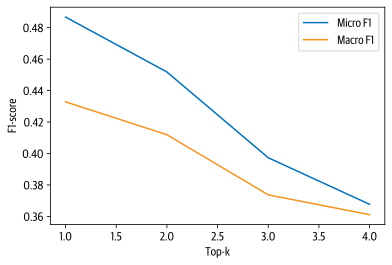

In [ ]:
plt.plot(topks, micros, label='Micro F1')
plt.plot(topks, macros, label='Macro F1')
plt.xlabel("Top-k")
plt.ylabel("F1-score")
plt.legend(loc='best')
plt.show()
#como nosso dataset muitas vezes tem apenas uma label, aumentar  o numero de k
#reduz o F1 score

In [ ]:
#hide_output
#va,ps testar agora com o threshold
macros, micros = [], []
thresholds = np.linspace(0.01, 1, 100)
for threshold in thresholds:
    ds_zero_shot = ds_zero_shot.map(get_preds,
                                    fn_kwargs={"threshold": threshold})
    clf_report = get_clf_report(ds_zero_shot)
    micros.append(clf_report["micro avg"]["f1-score"])
    macros.append(clf_report["macro avg"]["f1-score"])

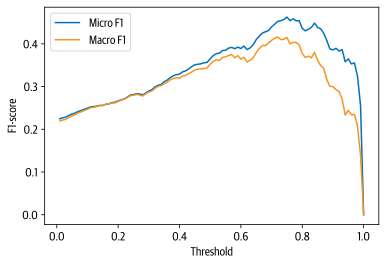

In [ ]:
plt.plot(thresholds, micros, label="Micro F1")
plt.plot(thresholds, macros, label="Macro F1")
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.legend(loc="best")
plt.show()

In [ ]:
best_t, best_micro = thresholds[np.argmax(micros)], np.max(micros)
print(f'Best threshold (micro): {best_t} with F1-score {best_micro:.2f}.')
best_t, best_macro = thresholds[np.argmax(macros)], np.max(macros)
print(f'Best threshold (micro): {best_t} with F1-score {best_macro:.2f}.')

#vamos verificar agora os melhores thresholds
#vejamos que o resultdao tambem nao foi bom , ate pior que alguns valores de k

Best threshold (micro): 0.75 with F1-score 0.46.
Best threshold (micro): 0.72 with F1-score 0.42.


**Vimos que nosso topk=1 entregou melhores resultados, vamos compará-lo com o naive bayes**

In [ ]:
#hide_output
ds_zero_shot = ds['test'].map(zero_shot_pipeline)
ds_zero_shot = ds_zero_shot.map(get_preds, fn_kwargs={'topk': 1})
clf_report = get_clf_report(ds_zero_shot)
for train_slice in train_slices:
    macro_scores['Zero Shot'].append(clf_report['macro avg']['f1-score'])
    micro_scores['Zero Shot'].append(clf_report['micro avg']['f1-score'])

  0%|          | 0/111 [00:00<?, ?ex/s]

/home/leandro/miniconda3/envs/tb/lib/python3.8/site-packages/transformers/pipelines/base.py:899: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(


  0%|          | 0/111 [00:00<?, ?ex/s]

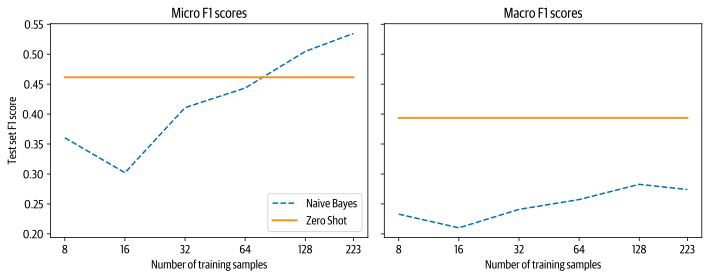

In [ ]:
plot_metrics(micro_scores, macro_scores, train_samples, "Zero Shot")

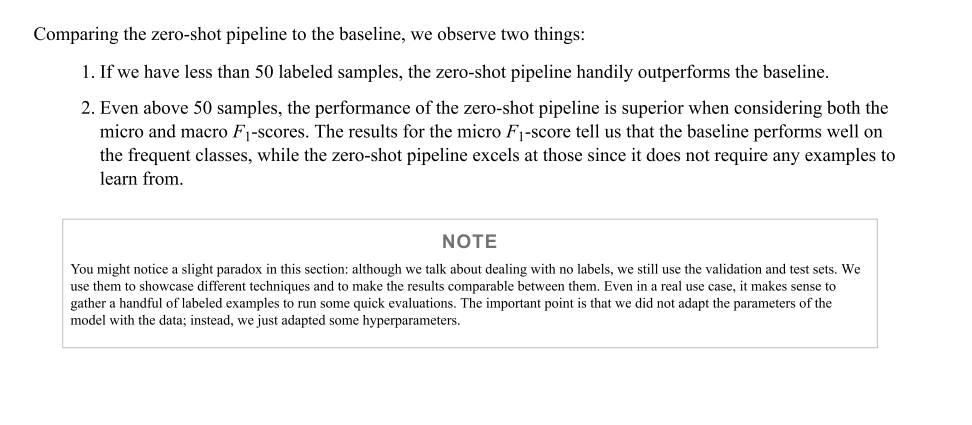

## Working with a Few Labels

### Data Augmentation

One simple but effective way to boost the performance of text classifiers on small datasets is to apply data augmentation techniques to generate new training examples from the existing ones. This is a common strategy in computer vision, where images are randomly perturbed without changing the meaning of the data (e.g., a slightly rotated cat is still a cat). For text, data augmentation is somewhat trickier because perturbing the words or characters can completely change the meaning. For example, the two questions “Are elephants heavier than mice?” and “Are mice heavier than elephants?” differ by a single word swap, but have opposite answers. However, if the text consists of more than a few sentences (like our GitHub issues do), then the noise introduced by these types of transformations will generally not affect the label. In practice, there are two types of data augmentation techniques that are commonly used:

 Back translation

 Take a text in the source language, translate it into one or more target languages using machine translation, and then translate it back to the source language. Back translation tends to works best for high-resource languages or corpora that don’t contain too many domain-specific words.

Token perturbations

Given a text from the training set, randomly choose and perform simple transformations like random synonym replacement, word insertion, swap, or deletion.
4

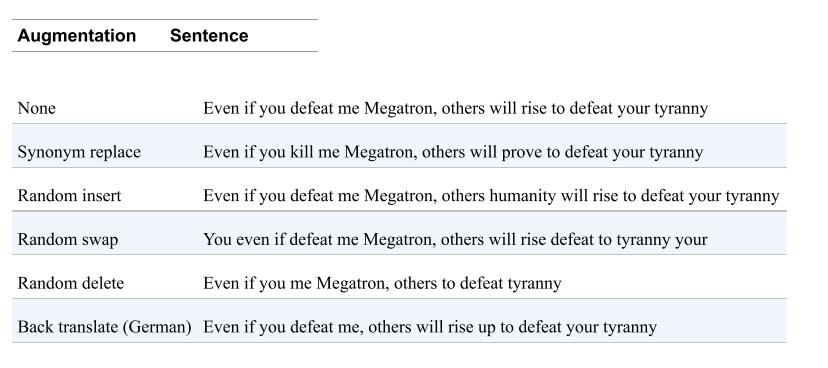

In [ ]:
#hide

#NLPaug é uma biblioteca que tem ferramentas para text augmentation
from transformers import set_seed
import nlpaug.augmenter.word as naw
import nlpaug.augmenter.char as nac
import nlpaug.augmenter.sentence as nas
import nlpaug.flow as nafc
import nltk
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')

set_seed(3)
text = "Even if you defeat me Megatron, others will rise to defeat your tyranny"
augs = {}
augs["synonym_replace"] = naw.SynonymAug(aug_src='wordnet')
augs["random_insert"] = naw.ContextualWordEmbsAug(model_path="distilbert-base-uncased",
                                device="cpu", action="insert", aug_max=1)
augs["random_swap"] = naw.RandomWordAug(action="swap")
augs["random_delete"] = naw.RandomWordAug()
augs["bt_en_de"] = naw.BackTranslationAug(
    from_model_name='facebook/wmt19-en-de',
    to_model_name='facebook/wmt19-de-en'
)
for k,v in augs.items():
    print(f"Original text: {text}")
    print(f"{k}: {v.augment(text)}")
    print("")

Original text: Even if you defeat me Megatron, others will rise to defeat your
tyranny
synonym_replace: Even if you kill me Megatron, others will prove to defeat your
tyranny

Original text: Even if you defeat me Megatron, others will rise to defeat your
tyranny


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/leandro/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /home/leandro/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


random_insert: even if you defeat me megatron, others humanity will rise to
defeat your tyranny

Original text: Even if you defeat me Megatron, others will rise to defeat your
tyranny
random_swap: You even if defeat me Megatron, others will rise defeat to tyranny
your

Original text: Even if you defeat me Megatron, others will rise to defeat your
tyranny
random_delete: Even if you me Megatron, others to defeat tyranny

Original text: Even if you defeat me Megatron, others will rise to defeat your
tyranny
bt_en_de: Even if you defeat me, others will rise to defeat your tyranny



In [ ]:
from transformers import set_seed
import nlpaug.augmenter.word as naw

set_seed(3)
# ele vai usar um modelo de linguagem para substituir as palavras
#action="substitute": Substitui palavras (ou tokens) por outras
#que façam sentido no mesmo contexto.
aug = naw.ContextualWordEmbsAug(model_path="distilbert-base-uncased",
                                device="cpu", action="substitute")

text = "Transformers are the most popular toys"
print(f"Original text: {text}")
print(f"Augmented text: {aug.augment(text)}")

Original text: Transformers are the most popular toys
Augmented text: transformers'the most popular toys


In [ ]:
def augment_text(batch, transformations_per_example=1):
    text_aug, label_ids = [], []
    for text, labels in zip(batch["text"], batch["label_ids"]):
        text_aug += [text]
        label_ids += [labels]
        for _ in range(transformations_per_example):
            text_aug += [aug.augment(text)]
            label_ids += [labels]
    return {"text": text_aug, "label_ids": label_ids}

    #aqui ele cria um datasr com os textos originais e os aumentados

In [ ]:
#hide
# vamos trabalhar com nossos slices progressivos selecionados anteriormente
for train_slice in train_slices:
    # Get training slice and test data
    ds_train_sample = ds["train"].select(train_slice)
    # Flatten augmentations and align labels!
    # vai aplicar a função de aumento em lote
    # como a funçao augmented_text retorna novas colunas, deleta-se as anteriores
    ds_train_aug = (ds_train_sample.map(
        augment_text, batched=True, remove_columns=ds_train_sample.column_names)
                    .shuffle(seed=42))
    y_train = np.array(ds_train_aug["label_ids"])
    y_test = np.array(ds["test"]["label_ids"])
    # Use a simple count vectorizer to encode our texts as token counts
    # como vamos regazer o naive bays, vamos aplicar o bag of words
    count_vect = CountVectorizer()
    X_train_counts = count_vect.fit_transform(ds_train_aug["text"])
    X_test_counts = count_vect.transform(ds["test"]["text"])
    # Create and train our model!
    classifier = BinaryRelevance(classifier=MultinomialNB())
    classifier.fit(X_train_counts, y_train)
    # Generate predictions and evaluate
    y_pred_test = classifier.predict(X_test_counts)
    clf_report = classification_report(
        y_test, y_pred_test, target_names=mlb.classes_, zero_division=0,
        output_dict=True)
    # Store metrics
    macro_scores["Naive Bayes + Aug"].append(clf_report["macro avg"]["f1-score"])
    micro_scores["Naive Bayes + Aug"].append(clf_report["micro avg"]["f1-score"])

  0%|          | 0/1 [00:00<?, ?ba/s]

  0%|          | 0/1 [00:00<?, ?ba/s]

  0%|          | 0/1 [00:00<?, ?ba/s]

  0%|          | 0/1 [00:00<?, ?ba/s]

  0%|          | 0/1 [00:00<?, ?ba/s]

  0%|          | 0/1 [00:00<?, ?ba/s]

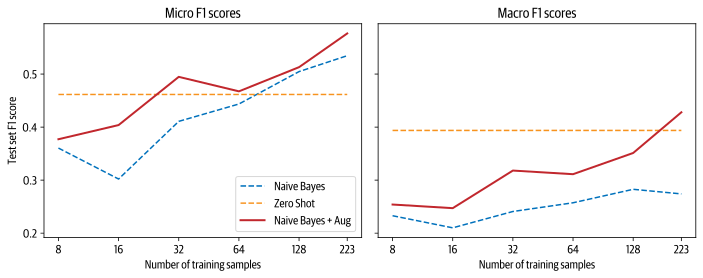

In [ ]:
#vamos ver o novo desempenho do naive bayes com os dados aumentados
plot_metrics(micro_scores, macro_scores, train_samples, "Naive Bayes + Aug")

### Using Embeddings as a Lookup Table

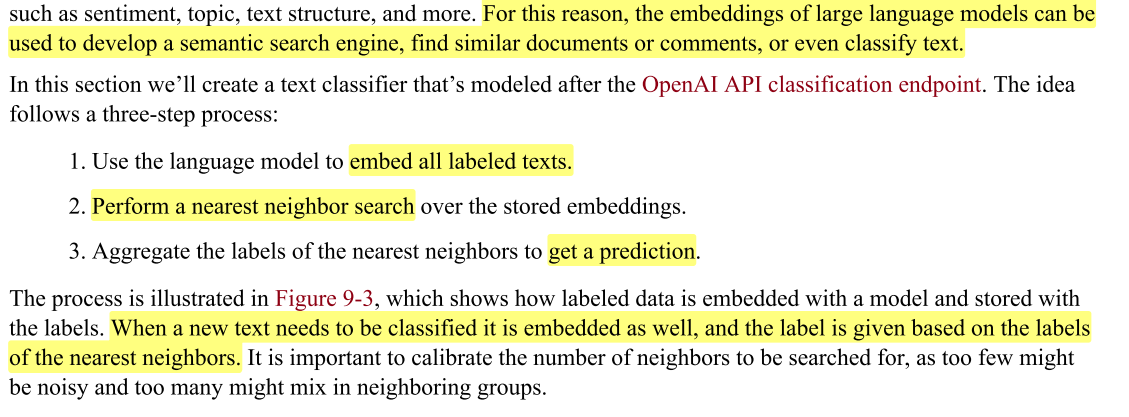

<img alt="nearest-neighbours" caption="An illustration of nearest neighbor embedding lookup" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter09_nearest-neighbours.png?raw=1" id="nearest-neighbours"/>

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel

# o ideal é escolher um modelo de embedding que seja pre treinado num campo similar
# aqui vamos usar o gpt2 como teste, mas ele tem um problema
# ele gera um emebedding por token e queremos um por sentença
# para resolver isso vamos usar o mean pooling
# como nao podemos incluir pad tokens no pooling, temos que colocar a mascara
model_ckpt = "miguelvictor/python-gpt2-large"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModel.from_pretrained(model_ckpt)

def mean_pooling(model_output, attention_mask):
    # Extract the token embeddings
    token_embeddings = model_output[0]
    # Compute the attention mask
    #expand é necessário porque os embeddings têm 3 dimensões: (batch_size, seq_len, hidden_size)
    #unsqueeze cria essa dimensão necessaroa
    input_mask_expanded = (attention_mask
                           .unsqueeze(-1)
                           .expand(token_embeddings.size())
                           .float())
    # Sum the embeddings, but ignore masked tokens
  # agora que temos a masara expandida para cada componente do nosso embedding podemos:
    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
    sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
    #sum(1) está somando o eixo dos tokens
    #clamp garante que os valores nunca caiam abaixo do minimo, evita div por zero
    # Return the average as a single vector
    return sum_embeddings / sum_mask

def embed_text(examples):
    inputs = tokenizer(examples["text"], padding=True, truncation=True,
                       max_length=128, return_tensors="pt")
    with torch.no_grad():
        model_output = model(**inputs)
    pooled_embeds = mean_pooling(model_output, inputs["attention_mask"])
    return {"embedding": pooled_embeds.cpu().numpy()}

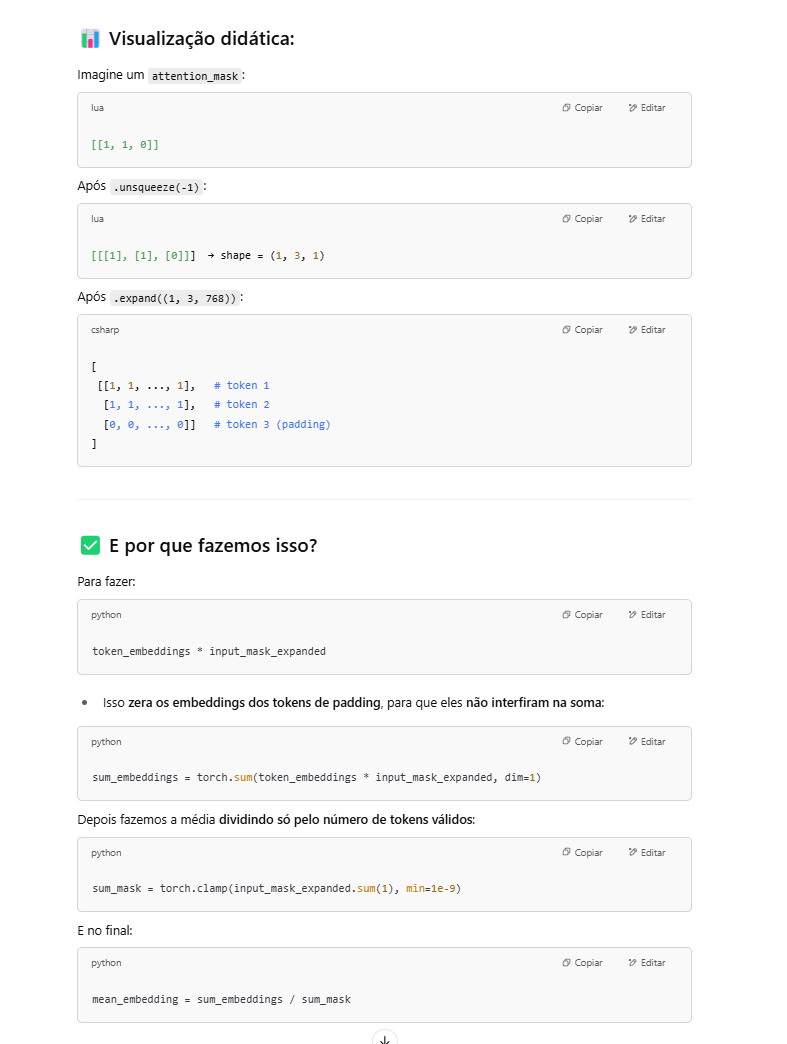

In [ ]:
# hide_output
tokenizer.pad_token = tokenizer.eos_token
embs_train = ds["train"].map(embed_text, batched=True, batch_size=16)
embs_valid = ds["valid"].map(embed_text, batched=True, batch_size=16)
embs_test = ds["test"].map(embed_text, batched=True, batch_size=16)
#Agora que temos os embeedings, precisamos definir um sistema de busca

  0%|          | 0/14 [00:00<?, ?ba/s]

  0%|          | 0/7 [00:00<?, ?ba/s]

  0%|          | 0/7 [00:00<?, ?ba/s]

In [ ]:
# hide_output
# Vamos criar um FAISS index para a colunaembedding
embs_train.add_faiss_index("embedding")

  0%|          | 0/1 [00:00<?, ?it/s]

Dataset({
    features: ['embedding', 'label_ids', 'labels', 'text'],
    num_rows: 223
})

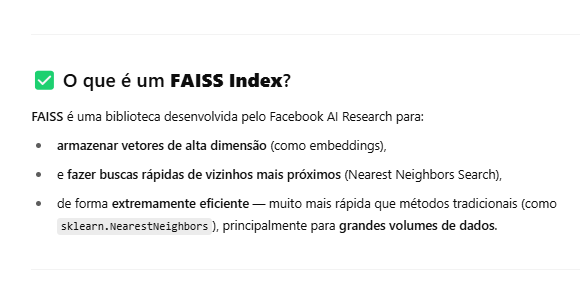

In [ ]:
i, k = 0, 3 # Select the first query and 3 nearest neighbors
rn, nl = "\r\n\r\n", "\n" # Used to remove newlines in text for compact display
#podemos agora fazer buscas pela similaridade com get_nearest_exampels
#vamos puxar do dataset validação
# i é zero porque foi defnido pra testar o primeiro
query =  np.array(embs_valid[i]["embedding"], dtype=np.float32)
#agora vamos fazer a busca
scores, samples = embs_train.get_nearest_examples("embedding", query, k=k)

print(f"QUERY LABELS: {embs_valid[i]['labels']}")
print(f"QUERY TEXT:\n{embs_valid[i]['text'][:200].replace(rn, nl)} [...]\n")
print("="*50)
print(f"Retrieved documents:")
for score, label, text in zip(scores, samples["labels"], samples["text"]):
    print("="*50)
    print(f"TEXT:\n{text[:200].replace(rn, nl)} [...]")
    print(f"SCORE: {score:.2f}")
    print(f"LABELS: {label}")

QUERY LABELS: ['new model']
QUERY TEXT:
Implementing efficient self attention in T5

# 🌟 New model addition
My teammates and I (including @ice-americano) would like to use efficient self
attention methods such as Linformer, Performer and [...]

Retrieved documents:
TEXT:
Add Linformer model

# 🌟 New model addition
## Model description
### Linformer: Self-Attention with Linear Complexity
Paper published June 9th on ArXiv: https://arxiv.org/abs/2006.04768
La [...]
SCORE: 54.92
LABELS: ['new model']
TEXT:
Add FAVOR+ / Performer attention

# 🌟 FAVOR+ / Performer attention addition
Are there any plans to add this new attention approximation block to
Transformers library?
## Model description
The n [...]
SCORE: 57.90
LABELS: ['new model']
TEXT:
Implement DeLighT: Very Deep and Light-weight Transformers

# 🌟 New model addition
## Model description
DeLight, that delivers similar or better performance than transformer-based
models with sign [...]
SCORE: 60.12
LABELS: ['new model']


In [ ]:
#vamos ver qual o melhor valro de k
def get_sample_preds(sample, m):
  #m vai ser o numero de vezes que a label aparece ao retornar k similares
    return (np.sum(sample["label_ids"], axis=0) >= m).astype(int)

def find_best_k_m(ds_train, valid_queries, valid_labels, max_k=17):
    max_k = min(len(ds_train), max_k)
    perf_micro = np.zeros((max_k, max_k))
    perf_macro = np.zeros((max_k, max_k))
    for k in range(1, max_k):
        for m in range(1, k + 1):
            _, samples = ds_train.get_nearest_examples_batch("embedding",
                                                             valid_queries, k=k)
            y_pred = np.array([get_sample_preds(s, m) for s in samples])
            clf_report = classification_report(valid_labels, y_pred,
                target_names=mlb.classes_, zero_division=0, output_dict=True)
            perf_micro[k, m] = clf_report["micro avg"]["f1-score"]
            perf_macro[k, m] = clf_report["macro avg"]["f1-score"]
    return perf_micro, perf_macro

In [ ]:
valid_labels = np.array(embs_valid["label_ids"])
valid_queries = np.array(embs_valid["embedding"], dtype=np.float32)
perf_micro, perf_macro = find_best_k_m(embs_train, valid_queries, valid_labels)

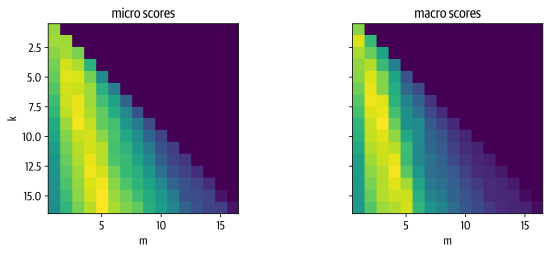

In [ ]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
ax0.imshow(perf_micro)
ax1.imshow(perf_macro)

ax0.set_title("micro scores")
ax0.set_ylabel("k")
ax1.set_title("macro scores")
for ax in [ax0, ax1]:
    ax.set_xlim([0.5, 17 - 0.5])
    ax.set_ylim([17 - 0.5, 0.5])
    ax.set_xlabel("m")
plt.show()

In [ ]:
k, m = np.unravel_index(perf_micro.argmax(), perf_micro.shape)
print(f"Best k: {k}, best m: {m}")

#vamos ver o melhor valor de k e m para otimizar nossa pesquisa

Best k: 15, best m: 5


In [ ]:
# hide_output
# vamos ffazer algo parecido com o naive bayes, avaliando a performance dos nossos
#slices de treino e comparando com nosso resultado
# O que iremos fazer é aplicar o mesmo conceito de slice, aplicar o indice faiss
#depois vamos retornar k e atribuir as labels conforme nosso m
#depois vamos comparar com os ground truths e avaliar o modelo
embs_train.drop_index("embedding") # vamos retirar os index iniciais
test_labels = np.array(embs_test["label_ids"])
test_queries = np.array(embs_test["embedding"], dtype=np.float32)

# a busca agora vai ser feita apenas dentro do slice, para podermos comparar
#de forma justa com o naive bayes
for train_slice in train_slices:
    # Create a FAISS index from training slice
    embs_train_tmp = embs_train.select(train_slice)
    #vamos fazer o index faiss para o slice
    embs_train_tmp.add_faiss_index("embedding")
    # Get best k, m values with validation set
    perf_micro, _ = find_best_k_m(embs_train_tmp, valid_queries, valid_labels)
    k, m = np.unravel_index(perf_micro.argmax(), perf_micro.shape)
    # Get predictions on test set
    _, samples = embs_train_tmp.get_nearest_examples_batch("embedding",
                                                           test_queries,
                                                           k=int(k))
    y_pred = np.array([get_sample_preds(s, m) for s in samples])
    # Evaluate predictions
    clf_report = classification_report(test_labels, y_pred,
        target_names=mlb.classes_, zero_division=0, output_dict=True,)
    macro_scores["Embedding"].append(clf_report["macro avg"]["f1-score"])
    micro_scores["Embedding"].append(clf_report["micro avg"]["f1-score"])

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

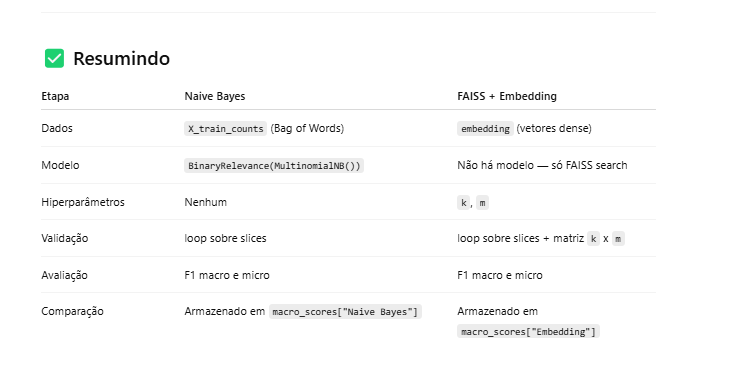

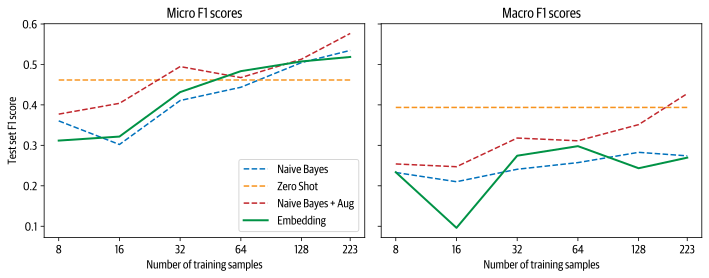

In [ ]:
plot_metrics(micro_scores, macro_scores, train_samples, "Embedding")

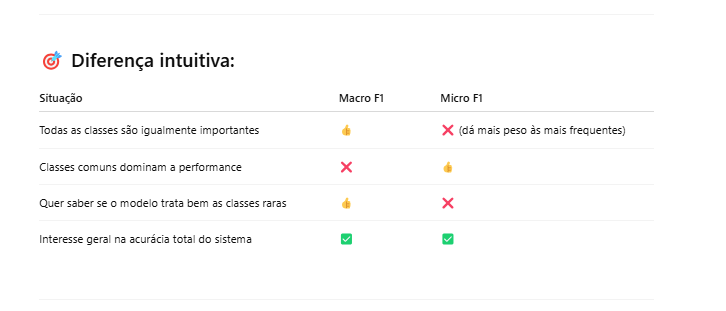

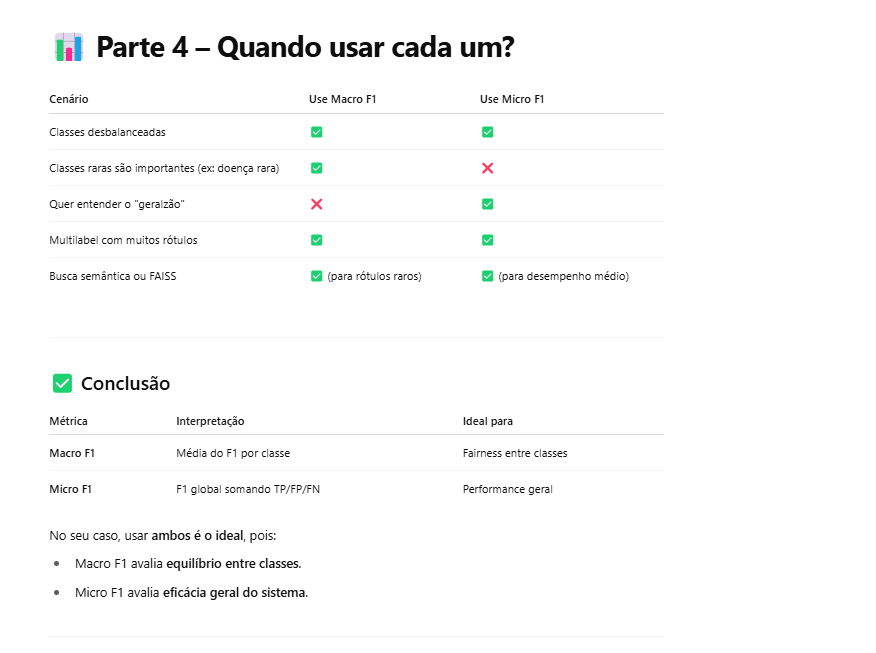

### Sidebar: Efficient Similarity Search with FAISS

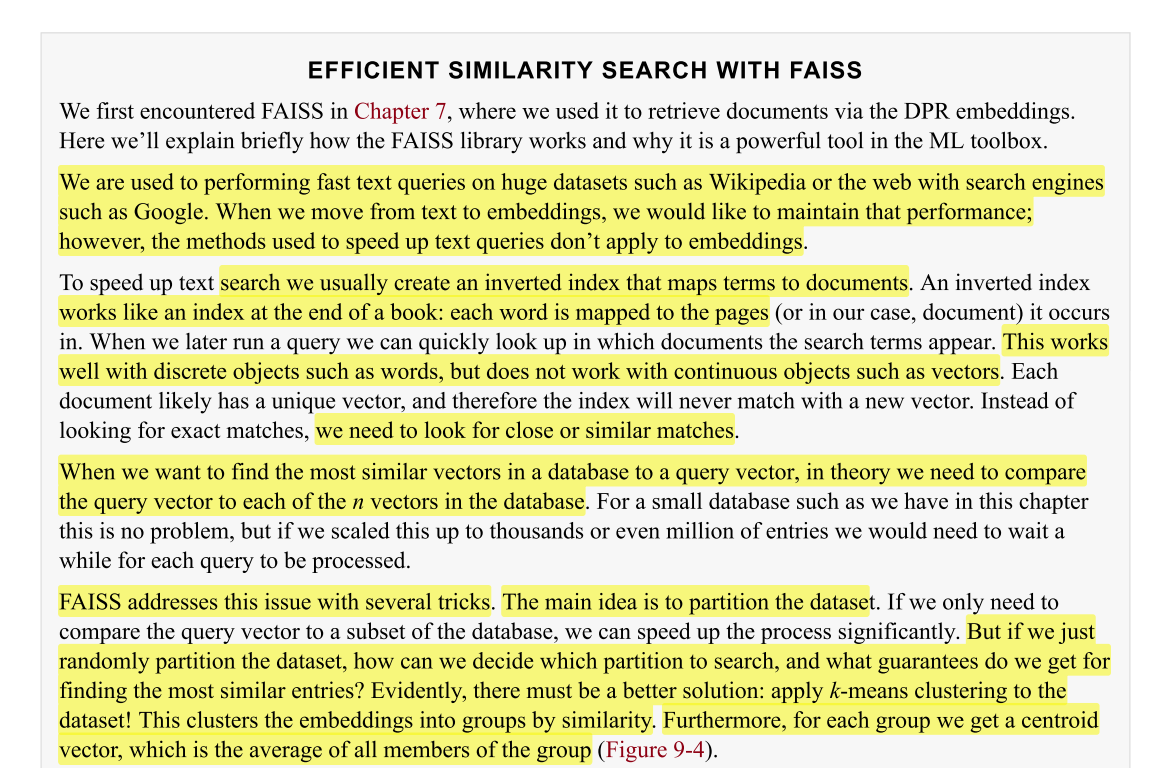

<img alt="faiss-index" caption="The structure of a FAISS index: the gray points represent data points added to the index, the bold black points are the cluster centers found via k-means clustering, and the colored areas represent the regions belonging to a cluster center" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter09_faiss-index.png?raw=1" id="faiss-index"/>

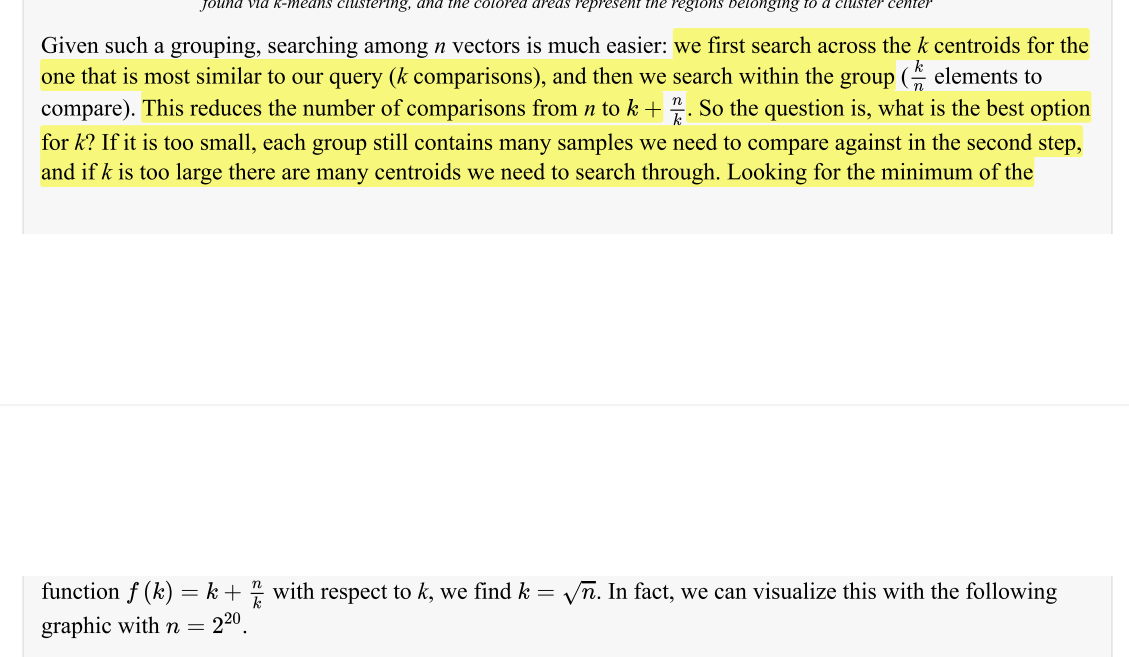

### End sidebar

### Fine-Tuning a Vanilla Transformer

In [ ]:
#hide_output
import torch
from transformers import (AutoTokenizer, AutoConfig,
                          AutoModelForSequenceClassification)

model_ckpt = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)
ds_enc = ds.map(tokenize, batched=True)
ds_enc = ds_enc.remove_columns(['labels', 'text'])

  0%|          | 0/1 [00:00<?, ?ba/s]

  0%|          | 0/1 [00:00<?, ?ba/s]

  0%|          | 0/1 [00:00<?, ?ba/s]

  0%|          | 0/10 [00:00<?, ?ba/s]

In [ ]:
#hide_output
ds_enc.set_format("torch")
ds_enc = ds_enc.map(lambda x: {"label_ids_f": x["label_ids"].to(torch.float)},
                    remove_columns=["label_ids"])
ds_enc = ds_enc.rename_column("label_ids_f", "label_ids")

  0%|          | 0/223 [00:00<?, ?ex/s]

  0%|          | 0/106 [00:00<?, ?ex/s]

  0%|          | 0/111 [00:00<?, ?ex/s]

  0%|          | 0/9303 [00:00<?, ?ex/s]

In [ ]:
from transformers import Trainer, TrainingArguments

training_args_fine_tune = TrainingArguments(
    output_dir="./results", num_train_epochs=20, learning_rate=3e-5,
    lr_scheduler_type='constant', per_device_train_batch_size=4,
    per_device_eval_batch_size=32, weight_decay=0.0,
    evaluation_strategy="epoch", save_strategy="epoch",logging_strategy="epoch",
    load_best_model_at_end=True, metric_for_best_model='micro f1',
    save_total_limit=1, log_level='error')

In [ ]:
from scipy.special import expit as sigmoid

def compute_metrics(pred):
    y_true = pred.label_ids
    y_pred = sigmoid(pred.predictions)
    y_pred = (y_pred>0.5).astype(float)

    clf_dict = classification_report(y_true, y_pred, target_names=all_labels,
                                     zero_division=0, output_dict=True)
    return {"micro f1": clf_dict["micro avg"]["f1-score"],
            "macro f1": clf_dict["macro avg"]["f1-score"]}

In [ ]:
#hide_output
config = AutoConfig.from_pretrained(model_ckpt)
config.num_labels = len(all_labels)
config.problem_type = "multi_label_classification"

In [ ]:
# hide_output
for train_slice in train_slices:
    model = AutoModelForSequenceClassification.from_pretrained(model_ckpt,
                                                               config=config)
    trainer = Trainer(
        model=model, tokenizer=tokenizer,
        args=training_args_fine_tune,
        compute_metrics=compute_metrics,
        train_dataset=ds_enc["train"].select(train_slice),
        eval_dataset=ds_enc["valid"],)

    trainer.train()
    pred = trainer.predict(ds_enc["test"])
    metrics = compute_metrics(pred)
    macro_scores["Fine-tune (vanilla)"].append(metrics["macro f1"])
    micro_scores["Fine-tune (vanilla)"].append(metrics["micro f1"])

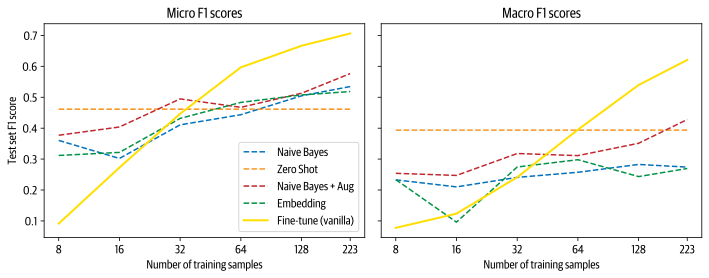

In [ ]:
plot_metrics(micro_scores, macro_scores, train_samples, "Fine-tune (vanilla)")

### In-Context and Few-Shot Learning with Prompts

In [ ]:
prompt = """\
Translate English to French:
thanks =>
"""

## Leveraging Unlabeled Data

### Fine-Tuning a Language Model

In [ ]:
#hide_output
def tokenize(batch):
    return tokenizer(batch["text"], truncation=True,
                     max_length=128, return_special_tokens_mask=True)

ds_mlm = ds.map(tokenize, batched=True)
ds_mlm = ds_mlm.remove_columns(["labels", "text", "label_ids"])

  0%|          | 0/1 [00:00<?, ?ba/s]

  0%|          | 0/1 [00:00<?, ?ba/s]

  0%|          | 0/1 [00:00<?, ?ba/s]

  0%|          | 0/10 [00:00<?, ?ba/s]

In [ ]:
from transformers import DataCollatorForLanguageModeling, set_seed

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,
                                                mlm_probability=0.15)

In [ ]:
set_seed(3)
data_collator.return_tensors = "np"
inputs = tokenizer("Transformers are awesome!", return_tensors="np")
outputs = data_collator([{"input_ids": inputs["input_ids"][0]}])

original_input_ids = inputs["input_ids"][0]
masked_input_ids = outputs["input_ids"][0]

pd.DataFrame({
    "Original tokens": tokenizer.convert_ids_to_tokens(original_input_ids),
    "Masked tokens": tokenizer.convert_ids_to_tokens(masked_input_ids),
    "Original input_ids": original_input_ids,
    "Masked input_ids": masked_input_ids,
    "Labels": outputs["labels"][0]}).T

,0,1,2,3,4,5
Original tokens,[CLS],transformers,are,awesome,!,[SEP]
Masked tokens,[CLS],transformers,are,awesome,[MASK],[SEP]
Original input_ids,101,19081,2024,12476,999,102
Masked input_ids,101,19081,2024,12476,103,102
Labels,-100,-100,-100,-100,999,-100


In [ ]:
data_collator.return_tensors = "pt"

In [ ]:
#hide_output
from transformers import AutoModelForMaskedLM

training_args = TrainingArguments(
    output_dir = f"{model_ckpt}-issues-128", per_device_train_batch_size=32,
    logging_strategy="epoch", evaluation_strategy="epoch", save_strategy="no",
    num_train_epochs=16, push_to_hub=True, log_level="error", report_to="none")

trainer = Trainer(
        model=AutoModelForMaskedLM.from_pretrained("bert-base-uncased"),
        tokenizer=tokenizer, args=training_args, data_collator=data_collator,
        train_dataset=ds_mlm["unsup"], eval_dataset=ds_mlm["train"])

trainer.train()

In [ ]:
# hide_output
trainer.push_to_hub("Training complete!")

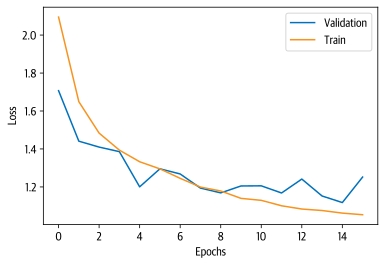

In [ ]:
df_log = pd.DataFrame(trainer.state.log_history)

(df_log.dropna(subset=["eval_loss"]).reset_index()["eval_loss"]
 .plot(label="Validation"))
df_log.dropna(subset=["loss"]).reset_index()["loss"].plot(label="Train")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.show()

### Fine-Tuning a Classifier

In [ ]:
#hide_output
model_ckpt = f'{model_ckpt}-issues-128'
config = AutoConfig.from_pretrained(model_ckpt)
config.num_labels = len(all_labels)
config.problem_type = "multi_label_classification"

for train_slice in train_slices:
    model = AutoModelForSequenceClassification.from_pretrained(model_ckpt,
                                                               config=config)
    trainer = Trainer(
        model=model,
        tokenizer=tokenizer,
        args=training_args_fine_tune,
        compute_metrics=compute_metrics,
        train_dataset=ds_enc["train"].select(train_slice),
        eval_dataset=ds_enc["valid"],
    )

    trainer.train()
    pred = trainer.predict(ds_enc['test'])
    metrics = compute_metrics(pred)
    # DA refers to domain adaptation
    macro_scores['Fine-tune (DA)'].append(metrics['macro f1'])
    micro_scores['Fine-tune (DA)'].append(metrics['micro f1'])

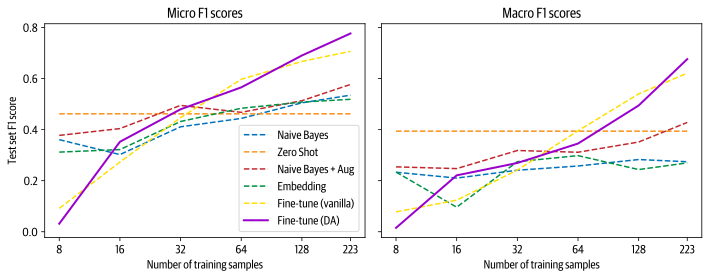

In [ ]:
plot_metrics(micro_scores, macro_scores, train_samples, "Fine-tune (DA)")

### Advanced Methods

#### Unsupervised data augmentation

<img alt="uda" width="600" caption="Training a model M with UDA (courtesy of Qizhe Xie)" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter09_uda.png?raw=1" id="uda"/>    

#### Uncertainty-aware self-training

<img alt="ust" width="600" caption="The UST method consists of a teacher that generates pseudo-labels and a student that is subsequently trained on those labels; after the student is trained it becomes the teacher and the step is repeated (courtesy of Subhabrata Mukherjee)footnote:[S. Mukherjee and A.H. Awadallah, ["Uncertainty-Aware Self-Training for Few-Shot Text Classification"](https://arxiv.org/abs/2006.15315), (2020).]" src="images/chapter09_ust.png" id="ust"/>

## Conclusion